# M2 — Is the frozen PFN surrogate trustworthy? (risk gate for §2.12)

Implements `docs/ROADMAP.md` §3 M2's exit criterion: standalone BO quality
with the frozen PFN as the surrogate (posterior mean/EI computed off its
predictive distribution), compared against a classical baseline on the
*same* tasks — a plain BoTorch GP + EI, per this project's own note
(the roadmap originally named PFNs4BO's HEBO+ model; a from-scratch
comparison against a code-identical-family GP+EI baseline is more useful
here and is what `models/baselines/gp_acquisition.py` already builds).

**Why this check exists (§2.12):** everything from M4 onward reads the PFN
as a stand-in for a real posterior. PFNs4BO's own strongest model is
trained on a *different* prior (HEBO+ GP) than this project's own
environment (the BNN prior, §1.6 — required, since only a callable
ground-truth environment supports the branch-and-replay data generation the
whole design depends on). So the prior that makes the best *environment*
might not make the best *surrogate* — this notebook is the check for
whether the BNN-prior-trained PFN is good enough to build a policy on top
of, or whether it's already a ceiling before any Q-head training starts.

**Checkpoint used:** `models/pfn_variable_xdim_smoke.pt`. Its experiment
config's own comment claims "Not a serious training run... 500 steps" —
**that comment is stale**: the checkpoint's own logged `history` (read
below) shows it actually trained for far longer. Trust the checkpoint's
logged history over the config comment when the two disagree.

**Method — a *shared task set*, per the exit criterion's wording:** each
policy (random, GP+EI, PFN-surrogate+EI) is rolled out against a
`BNNPrior` batch constructed with the *same seed*, so all three see
literally the same set of true functions (and the same initial `n_init`
context points) — differences in outcome are attributable to the policy,
not to which functions happened to be sampled. (Noise realizations along
each trajectory differ trivially anyway, since the policies query different
points — that's fine and unavoidable, unlike the function draws themselves.)

In [1]:
from functools import partial

import matplotlib.pyplot as plt
import torch

from anytimeacquisition.metrics.inc_auc import log_incumbent_auc
from anytimeacquisition.metrics.rollout import random_policy, rollout_episode
from anytimeacquisition.models.baselines.gp_acquisition import gp_acquisition_policy
from anytimeacquisition.models.surrogates.pfn_surrogate import PFNSurrogate, pfn_surrogate_ei_policy
from anytimeacquisition.pipelines.train_pfn import load_pfn_checkpoint
from anytimeacquisition.priors.bnn import BNNPrior
from anytimeacquisition.reward.tail_quantile_reward import build_ecdf, percentile
from anytimeacquisition.utils.paths import CHECKPOINT_DIR

pfn, bar_dist, ckpt = load_pfn_checkpoint(CHECKPOINT_DIR / "pfn_variable_xdim_smoke.pt")
surrogate = PFNSurrogate(pfn, bar_dist, use_bf16=False)  # bf16 autocast on CPU: correct but no speedup here
print(f"checkpoint config: {ckpt['config']}")
print(f"checkpoint actually trained for {max(ckpt['history']['step'])} steps "
      f"({len(ckpt['history']['step'])} logged points) -- ignore the experiment config's stale comment")

/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


checkpoint config: {'max_x_dim': 6, 'd_model': 64, 'n_heads': 4, 'n_layers': 4, 'd_ff': 128, 'n_bins': 64}
checkpoint actually trained for 29999 steps (301 logged points) -- ignore the experiment config's stale comment


## Run the shared-task comparison

Per-environment normalization, before the rollouts — **why**: `BNNPrior.evaluate()`
bounds every draw's output to `[0,1]`, but that calibration is fit once,
*pooled* across ~50 architecture draws (`BNNPrior._fit_ecdf`) — not
per-instance. Individual draws still differ a lot in their *achievable
range* inside `[0,1]`: some architectures are "easy" (span nearly all of
it), others are "flat"/hard (compressed into a narrow band). Averaging raw
incumbent values across environments lets the easy/wide-range ones dominate
the mean and hides whether the policy is doing well *relative to what each
task actually offers*.

**Standard BO practice for exactly this** — aggregating across heterogeneous
benchmark instances — is to report *normalized regret* / *percentile-of-domain*
per task, not raw values: `(f - f_min)/(f_max - f_min)` when the optimum is
known, or, when it isn't but dense evaluation is available (true here —
privileged/ground-truth access), the empirical-CDF percentile against a
per-instance reference sample. That's exactly `docs/ROADMAP.md` §M1's own
`build_ecdf`/`percentile` — reused here rather than inventing a separate
normalization.

`matching_reference` reconstructs each `x_dim`'s exact environments (same
seed -> same architectures, verified against what `rollout_episode`'s own
internal `reset()` draws) purely to build this per-instance reference —
it does not affect the rollouts themselves.

In [2]:
BATCH_SIZE = 10  # 10 independent environments (BNN function draws) per x_dim, shared across all 3 policies
N_INIT, N_STEPS = 3, 12
POLICY_SEED = 1  # candidate-proposal randomness (GP restarts, PFN's Sobol pool) -- independent of the task seed
REFERENCE_N = 100_000  # Sobol reference size per environment, matching M1's build_ecdf default

POLICIES = {
    "random": lambda: random_policy,
    "gp_ei": lambda: partial(gp_acquisition_policy, acquisition="EI", num_restarts=5, raw_samples=64),
    "pfn_surrogate_ei": lambda: partial(pfn_surrogate_ei_policy, surrogate=surrogate, n_candidates=256, seed=POLICY_SEED),
}


def matching_reference(x_dim: int, task_seed: int):
    """Same seed/batch/x_dim as run_shared_task_comparison below, plus one
    extra explicit reset() -- reproduces the exact environments
    rollout_episode's own internal reset() draws (verified: construct + its
    own __init__ reset, then rollout_episode's reset() is architecture-draw
    #2 relative to the seed; an independently constructed prior + one more
    explicit .reset() lands on that same #2 draw)."""
    prior = BNNPrior(batch_size=BATCH_SIZE, x_dim=x_dim, seed=task_seed)
    prior.reset()
    return build_ecdf(prior, n_samples=REFERENCE_N, seed=1)


def normalized_score(y_context: torch.Tensor, y_sorted: torch.Tensor) -> torch.Tensor:
    """Per-instance-normalized incumbent trajectory, in [0,1] -- 1.0 means
    the incumbent has already beaten virtually the entire per-instance
    reference sample (this project minimizes, so "beaten" = smaller), 0.0
    means it's at the very worst end. Directly comparable across
    environments with different intrinsic scales, unlike raw y."""
    incumbent = torch.cummin(y_context, dim=1).values  # [B, T]
    u = percentile(y_sorted, incumbent)  # [B, T], fraction of the reference AT OR BELOW the incumbent
    return 1.0 - u


def run_shared_task_comparison(x_dim: int, task_seed: int = 0):
    y_sorted = matching_reference(x_dim, task_seed)
    rollouts = {}
    for name, make_policy in POLICIES.items():
        torch.manual_seed(task_seed)
        prior = BNNPrior(batch_size=BATCH_SIZE, x_dim=x_dim, seed=task_seed)  # same seed -> same functions
        rollouts[name] = rollout_episode(prior, n_init=N_INIT, n_steps=N_STEPS, policy_fn=make_policy())
    return rollouts, y_sorted


results = {}
for x_dim in (1, 2):
    rollouts, y_sorted = run_shared_task_comparison(x_dim)
    aucs = {name: log_incumbent_auc(r["y_context"]) for name, r in rollouts.items()}
    norm_scores = {name: normalized_score(r["y_context"], y_sorted) for name, r in rollouts.items()}
    results[x_dim] = {"rollouts": rollouts, "aucs": aucs, "norm_scores": norm_scores}

    print(f"--- x_dim={x_dim} (log-incumbent AUC: lower is better) ---")
    for name, auc in aucs.items():
        se = auc.std().item() / (BATCH_SIZE ** 0.5)
        print(f"  {name:20s} mean {auc.mean().item():8.4f}  +/- {se:.4f} (se, n={BATCH_SIZE})")
    gap = aucs["pfn_surrogate_ei"].mean().item() - aucs["gp_ei"].mean().item()
    print(f"  gap (pfn - gp, positive = GP still better): {gap:+.4f}")

    print(f"--- x_dim={x_dim} (normalized score, mean over steps AND envs: higher is better, in [0,1]) ---")
    for name, ns in norm_scores.items():
        mean_over_steps = ns.mean(dim=1)  # [B] -- anytime average per environment
        se = mean_over_steps.std().item() / (BATCH_SIZE ** 0.5)
        print(f"  {name:20s} mean {mean_over_steps.mean().item():.4f}  +/- {se:.4f} (se, n={BATCH_SIZE})")
    norm_gap = norm_scores["pfn_surrogate_ei"].mean(dim=1).mean().item() - norm_scores["gp_ei"].mean(dim=1).mean().item()
    print(f"  gap (pfn - gp, positive = PFN better here): {norm_gap:+.4f}")

--- x_dim=1 (log-incumbent AUC: lower is better) ---
  random               mean -20.2902  +/- 6.8688 (se, n=10)
  gp_ei                mean -19.8996  +/- 6.8641 (se, n=10)
  pfn_surrogate_ei     mean -21.6950  +/- 7.8391 (se, n=10)
  gap (pfn - gp, positive = GP still better): -1.7954
--- x_dim=1 (normalized score, mean over steps AND envs: higher is better, in [0,1]) ---
  random               mean 0.8683  +/- 0.0301 (se, n=10)
  gp_ei                mean 0.8271  +/- 0.0519 (se, n=10)
  pfn_surrogate_ei     mean 0.8895  +/- 0.0305 (se, n=10)
  gap (pfn - gp, positive = PFN better here): +0.0624


--- x_dim=2 (log-incumbent AUC: lower is better) ---
  random               mean -14.5803  +/- 2.1850 (se, n=10)
  gp_ei                mean -15.0559  +/- 2.5461 (se, n=10)
  pfn_surrogate_ei     mean -15.3454  +/- 2.4212 (se, n=10)
  gap (pfn - gp, positive = GP still better): -0.2895
--- x_dim=2 (normalized score, mean over steps AND envs: higher is better, in [0,1]) ---
  random               mean 0.8394  +/- 0.0267 (se, n=10)
  gp_ei                mean 0.8572  +/- 0.0394 (se, n=10)
  pfn_surrogate_ei     mean 0.8773  +/- 0.0205 (se, n=10)
  gap (pfn - gp, positive = PFN better here): +0.0201


## Incumbent trajectories — normalized per environment, individual + mean

Every one of the `BATCH_SIZE` (10) shared environments' own **normalized**
incumbent curve (see above — fraction of that environment's own reference
sample beaten so far, `1.0` = essentially at its own achievable optimum),
per policy (thin lines) plus the mean across them (bold). Normalizing first
is what makes this plot actually readable: 10 raw-`y` curves on wildly
different intrinsic scales mostly just show which *environment* was easy,
not which *policy* was good.

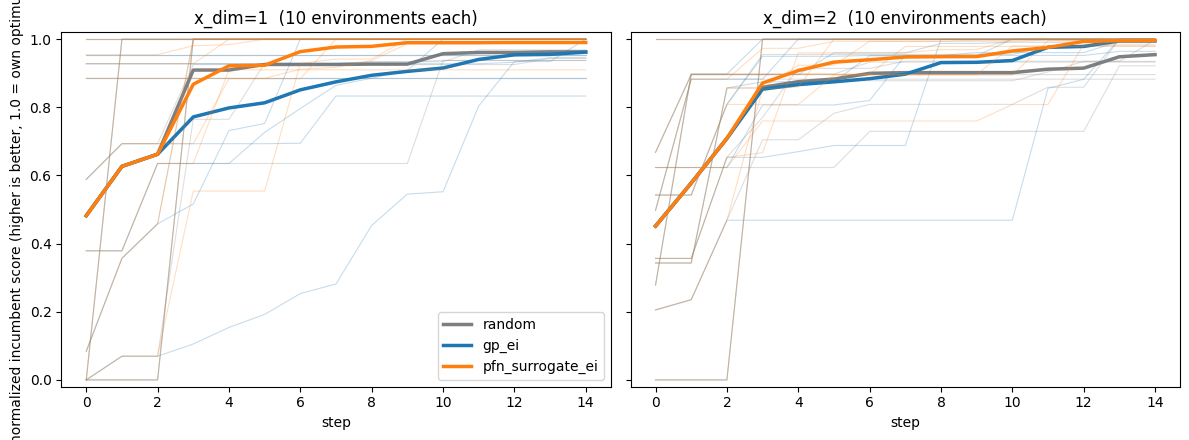

In [3]:
POLICY_COLORS = {"random": "tab:gray", "gp_ei": "tab:blue", "pfn_surrogate_ei": "tab:orange"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, x_dim in zip(axes, (1, 2)):
    for name, ns in results[x_dim]["norm_scores"].items():
        color = POLICY_COLORS[name]
        for row in ns:
            ax.plot(row, color=color, alpha=0.25, linewidth=0.8)
        ax.plot(ns.mean(dim=0), color=color, linewidth=2.5, label=name)
    ax.set_title(f"x_dim={x_dim}  ({BATCH_SIZE} environments each)")
    ax.set_xlabel("step")
    ax.set_ylim(-0.02, 1.02)
axes[0].set_ylabel("normalized incumbent score (higher is better, 1.0 = own optimum)")
axes[0].legend()
plt.tight_layout()
plt.show()

## Cost curve: PFN forward time vs. context size `t` and candidate pool `C`

Second half of M2's exit criterion — confirms the `O(t(t+C))` attention
term and `O(C)` MLP term (§2.10), and gives a concrete number to pick `C`
from for later milestones' decision-time candidate pools.

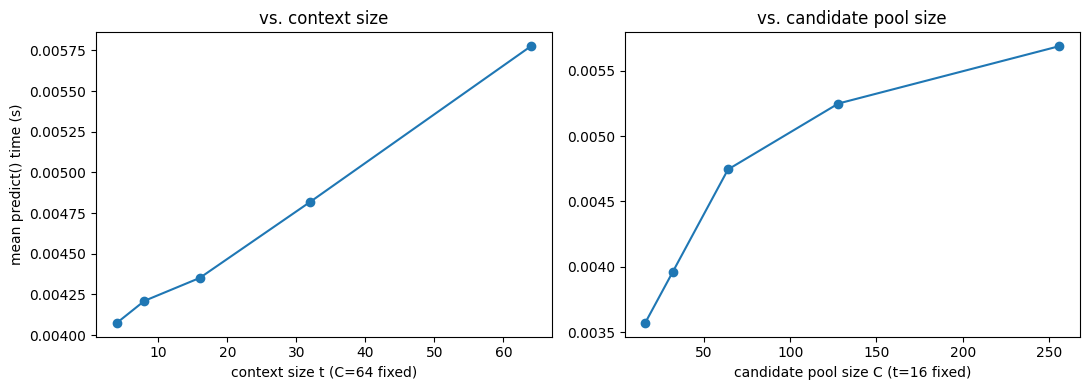

t=  4  C=64   predict() time: 4.08 ms
t=  8  C=64   predict() time: 4.21 ms
t= 16  C=64   predict() time: 4.35 ms
t= 32  C=64   predict() time: 4.82 ms
t= 64  C=64   predict() time: 5.78 ms
t=16  C=  16  predict() time: 3.57 ms
t=16  C=  32  predict() time: 3.96 ms
t=16  C=  64  predict() time: 4.75 ms
t=16  C= 128  predict() time: 5.25 ms
t=16  C= 256  predict() time: 5.69 ms


In [4]:
import time

def time_predict(t, C, n_repeats=5):
    prior = BNNPrior(batch_size=8, x_dim=2, seed=0)
    x_context, y_context, _, _ = prior.sample_episode(n_train=t, n_test=0)
    candidates = torch.rand(8, C, 2)
    surrogate.predict(x_context, y_context, candidates)  # warm-up (lazy imports, etc.)
    start = time.perf_counter()
    for _ in range(n_repeats):
        surrogate.predict(x_context, y_context, candidates)
    return (time.perf_counter() - start) / n_repeats


t_values = [4, 8, 16, 32, 64]
C_values = [16, 32, 64, 128, 256]

time_vs_t = [time_predict(t=t, C=64) for t in t_values]
time_vs_C = [time_predict(t=16, C=C) for C in C_values]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t_values, time_vs_t, marker="o")
axes[0].set_xlabel("context size t (C=64 fixed)")
axes[0].set_ylabel("mean predict() time (s)")
axes[0].set_title("vs. context size")
axes[1].plot(C_values, time_vs_C, marker="o")
axes[1].set_xlabel("candidate pool size C (t=16 fixed)")
axes[1].set_title("vs. candidate pool size")
plt.tight_layout()
plt.show()

for t, dt in zip(t_values, time_vs_t):
    print(f"t={t:3d}  C=64   predict() time: {dt*1000:.2f} ms")
for C, dt in zip(C_values, time_vs_C):
    print(f"t=16  C={C:4d}  predict() time: {dt*1000:.2f} ms")

## Summary

Recorded in `docs/ROADMAP.md` §M2 — see the exit-criterion checklist there
for the actual numbers this run produced (they're printed above, not
hand-copied into this cell, so a rerun on a different/better-trained
checkpoint stays the source of truth).

**Two gap numbers, read them the same direction:** the log-incumbent-AUC gap
(`pfn - gp`, positive = GP still better) and the normalized-score gap
(`pfn - gp`, positive = **PFN** better this time — normalized score is a
"higher is better" quantity) measure related but not identical things — the
first is raw-scale and can be dominated by a few wide-range environments,
the second is per-instance-normalized per the discussion above and is the
more standard-BO-practice number to trust for "which policy is actually
better across these heterogeneous tasks." Given the checkpoint actually
trained substantially longer than its stale config comment claimed (see the
"checkpoint actually trained for..." line above), these numbers carry more
weight than a smoke-scale reading would — still only `BATCH_SIZE` (10)
environments per dimension though, so treat this as an informative first
read, not the final word; widen `BATCH_SIZE` (and/or average over several
`task_seed`s) before leaning on it heavily.